In [452]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import math
import scipy.stats as stats
from ucimlrepo import fetch_ucirepo
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
import tensorflow as tf
from tensorflow import keras
from keras import layers
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier


statlog_heart = fetch_ucirepo(id=145)

df = statlog_heart.data.features.copy()
df['target'] = statlog_heart.data.targets

display(df.head())



,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,target
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


# Дескриптивный анализ

## Функция для вывода статистики

In [453]:
# Функция для построения гистограммы распределения признаков и вывода стастистики
def print_stats(dataframe, feature_name, k):
    plt.hist(dataframe[feature_name], bins=k, edgecolor='black')
    plt.title(f'Распределение признака {feature_name}')
    plt.xlabel(feature_name)
    plt.ylabel('Частота')

    shapiro_test = stats.shapiro(dataframe[feature_name])
    dagostino_test = stats.normaltest(dataframe[feature_name])
    ks_test = stats.kstest(
        dataframe[feature_name],
        'norm',
        args=(dataframe[feature_name].mean(), dataframe[feature_name].std())
    )

    def interpret_pvalue(p):
        if p > 0.05:
            return "Нормальное"
        elif p > 0.01:
            return "Близко к нормальному"
        else:
            return "Далеко от нормального"

    # Дескриптивный анализ
    print (
        f"Статистика для признака {feature_name}:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Среднее:                  | {dataframe[feature_name].mean()}\n"
        f"Медиана:                  | {dataframe[feature_name].median()}\n"
        f"Мода:                     | {dataframe[feature_name].mode()[0]}\n"
        f"Минимум:                  | {dataframe[feature_name].min()}\n"
        f"Максимум:                 | {dataframe[feature_name].max()}\n"
        f"Размах:                   | {dataframe[feature_name].max() - dataframe[feature_name].min()}\n"
        f"Стандартное отклонение:   | {dataframe[feature_name].std()}\n"
        f"Дисперсия:                | {dataframe[feature_name].var()}\n"
        f"Асимметрия:               | {dataframe[feature_name].skew()}\n"
        f"Эксцесс:                  | {dataframe[feature_name].kurtosis()}\n"
        f"Квантили (25%, 50%, 75%): | {dataframe[feature_name].quantile([0.25, 0.5, 0.75]).to_dict()}\n"
        f"Оценка нормальности распредления:\n"
        f"--------------------------|-------------------------------------------\n"
        f"Шапиро-Уилк:              | p={shapiro_test.pvalue:.3e} → {interpret_pvalue(shapiro_test.pvalue)}\n"
        f"Д'Агостино-Пиросона:      | p={dagostino_test.pvalue:.3e} → {interpret_pvalue(dagostino_test.pvalue)}\n"
        f"Колмагорова-Смирнова      | p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}\n"
    )



n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))
print(f"Количество записей: {n}")
print(f"Количество интервалов по формуле Стержиса: {k}")

Количество записей: 270
Количество интервалов по формуле Стержиса: 10


## age

Статистика для признака age:
--------------------------|-------------------------------------------
Среднее:                  | 54.43333333333333
Медиана:                  | 55.0
Мода:                     | 54.0
Минимум:                  | 29.0
Максимум:                 | 77.0
Размах:                   | 48.0
Стандартное отклонение:   | 9.109066523898207
Дисперсия:                | 82.97509293680295
Асимметрия:               | -0.16361522733654557
Эксцесс:                  | -0.5448153930171342
Квантили (25%, 50%, 75%): | {0.25: 48.0, 0.5: 55.0, 0.75: 61.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.765e-02 → Близко к нормальному
Д'Агостино-Пиросона:      | p=2.763e-02 → Близко к нормальному
Колмагорова-Смирнова      | p=1.755e-01 → Нормальное



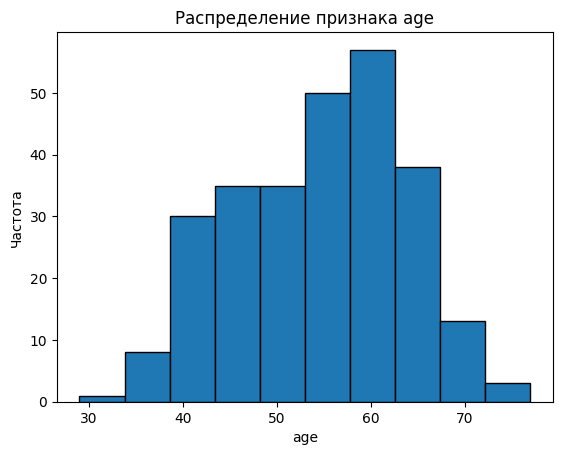

In [454]:
print_stats(df, "age", k)

## rest-bp

Статистика для признака rest-bp:
--------------------------|-------------------------------------------
Среднее:                  | 131.34444444444443
Медиана:                  | 130.0
Мода:                     | 120.0
Минимум:                  | 94.0
Максимум:                 | 200.0
Размах:                   | 106.0
Стандартное отклонение:   | 17.861608292800856
Дисперсия:                | 319.03705080545234
Асимметрия:               | 0.7226180070438306
Эксцесс:                  | 0.9230967359120847
Квантили (25%, 50%, 75%): | {0.25: 120.0, 0.5: 130.0, 0.75: 140.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=3.739e-06 → Далеко от нормального
Д'Агостино-Пиросона:      | p=2.198e-06 → Далеко от нормального
Колмагорова-Смирнова      | p=8.052e-03 → Далеко от нормального



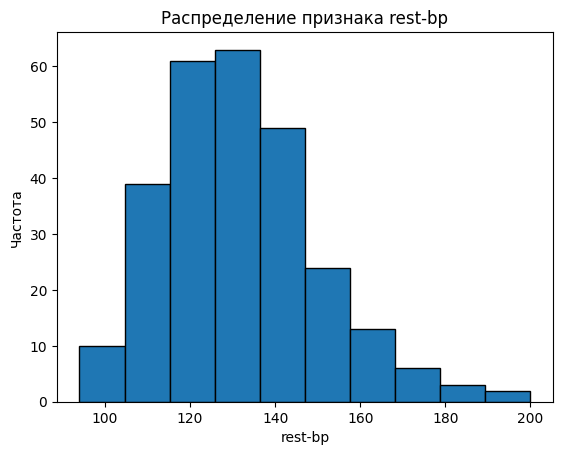

In [455]:
print_stats(df, "rest-bp", k)

## serum-chol

Статистика для признака serum-chol:
--------------------------|-------------------------------------------
Среднее:                  | 249.65925925925927
Медиана:                  | 245.0
Мода:                     | 234.0
Минимум:                  | 126.0
Максимум:                 | 564.0
Размах:                   | 438.0
Стандартное отклонение:   | 51.68623711643124
Дисперсия:                | 2671.4671072559545
Асимметрия:               | 1.1837208885656836
Эксцесс:                  | 4.895598990181746
Квантили (25%, 50%, 75%): | {0.25: 213.0, 0.5: 245.0, 0.75: 280.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.079e-08 → Далеко от нормального
Д'Агостино-Пиросона:      | p=4.539e-18 → Далеко от нормального
Колмагорова-Смирнова      | p=4.696e-01 → Нормальное



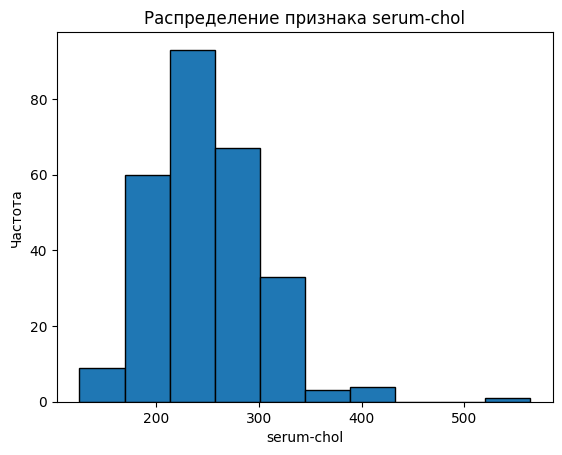

In [456]:
print_stats(df, "serum-chol", k)

## max-heart-rate

Статистика для признака max-heart-rate:
--------------------------|-------------------------------------------
Среднее:                  | 149.67777777777778
Медиана:                  | 153.5
Мода:                     | 162.0
Минимум:                  | 71.0
Максимум:                 | 202.0
Размах:                   | 131.0
Стандартное отклонение:   | 23.165716775120096
Дисперсия:                | 536.6504337050806
Асимметрия:               | -0.5277366828794363
Эксцесс:                  | -0.10307188534537648
Квантили (25%, 50%, 75%): | {0.25: 133.0, 0.5: 153.5, 0.75: 166.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.450e-04 → Далеко от нормального
Д'Агостино-Пиросона:      | p=2.847e-03 → Далеко от нормального
Колмагорова-Смирнова      | p=7.147e-02 → Нормальное



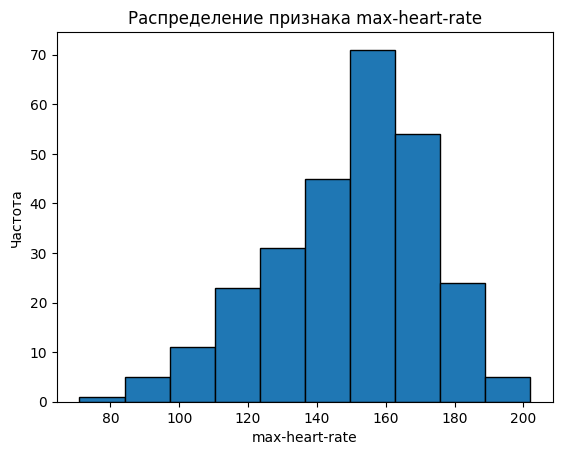

In [457]:
print_stats(df, "max-heart-rate", k)

## oldpeak

Статистика для признака oldpeak:
--------------------------|-------------------------------------------
Среднее:                  | 1.05
Медиана:                  | 0.8
Мода:                     | 0.0
Минимум:                  | 0.0
Максимум:                 | 6.2
Размах:                   | 6.2
Стандартное отклонение:   | 1.1452098393779973
Дисперсия:                | 1.3115055762081784
Асимметрия:               | 1.2628932110432118
Эксцесс:                  | 1.7593165294222333
Квантили (25%, 50%, 75%): | {0.25: 0.0, 0.5: 0.8, 0.75: 1.6}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=2.103e-15 → Далеко от нормального
Д'Агостино-Пиросона:      | p=5.120e-14 → Далеко от нормального
Колмагорова-Смирнова      | p=4.309e-08 → Далеко от нормального



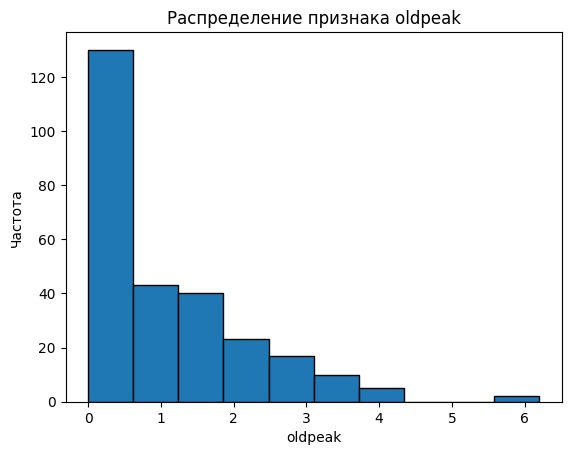

In [458]:
print_stats(df, "oldpeak", k)

## target

Статистика для признака target:
--------------------------|-------------------------------------------
Среднее:                  | 1.4444444444444444
Медиана:                  | 1.0
Мода:                     | 1
Минимум:                  | 1
Максимум:                 | 2
Размах:                   | 1
Стандартное отклонение:   | 0.4978267515886163
Дисперсия:                | 0.24783147459727387
Асимметрия:               | 0.22485794134254491
Эксцесс:                  | -1.9640428475599532
Квантили (25%, 50%, 75%): | {0.25: 1.0, 0.5: 1.0, 0.75: 2.0}
Оценка нормальности распредления:
--------------------------|-------------------------------------------
Шапиро-Уилк:              | p=1.040e-23 → Далеко от нормального
Д'Агостино-Пиросона:      | p=8.752e-295 → Далеко от нормального
Колмагорова-Смирнова      | p=1.372e-33 → Далеко от нормального



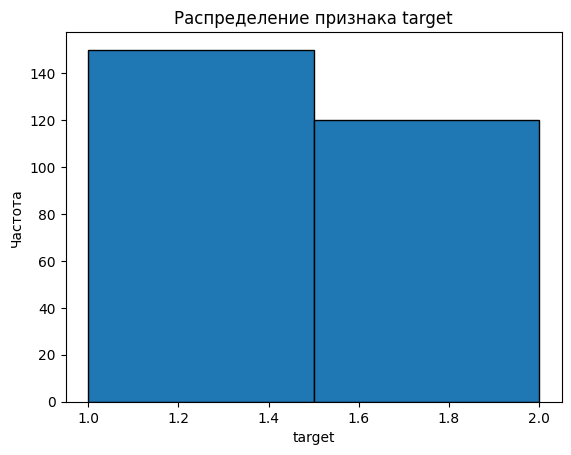

In [459]:
print_stats(df, "target", 2)

# Матрица корреляции

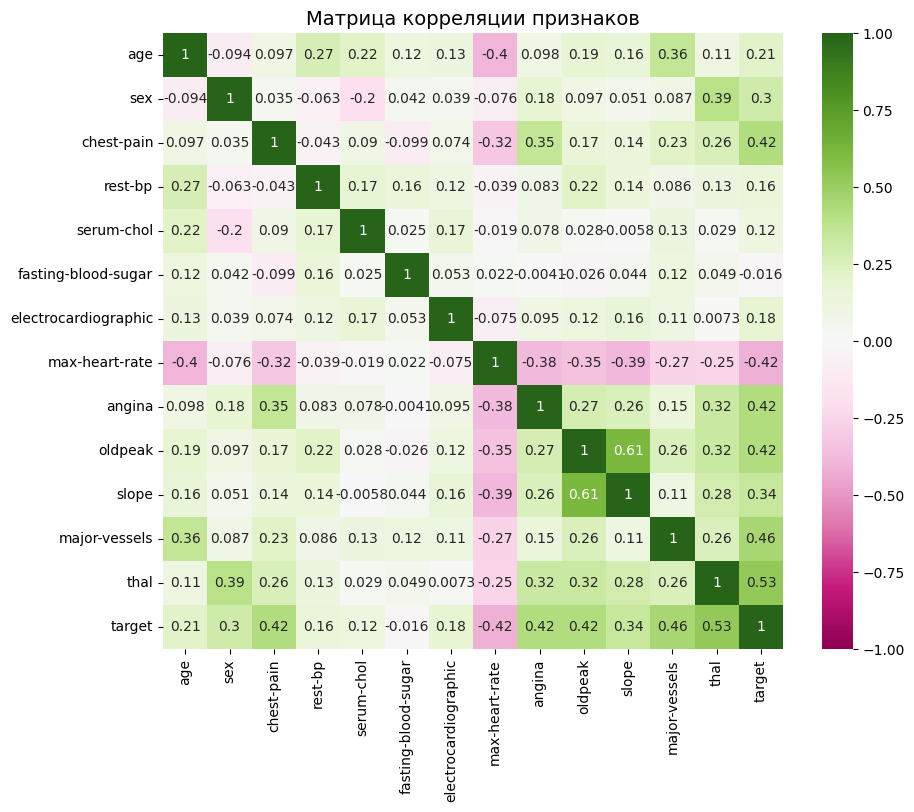

In [460]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='PiYG', vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков", fontsize=14)
plt.show()

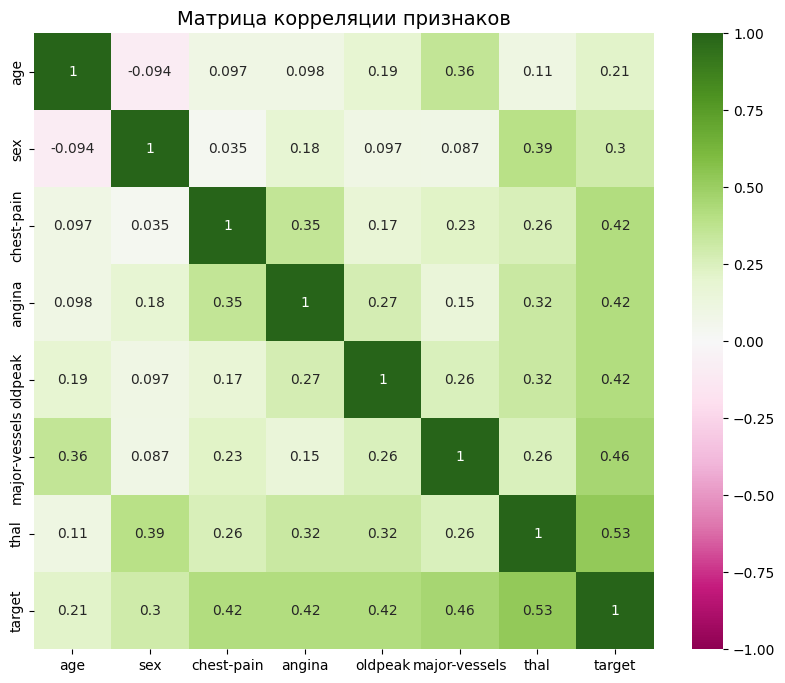

In [461]:
df = df.drop(columns=["slope"])
df = df.drop(columns=["max-heart-rate"])
df = df.drop(columns=["rest-bp"])
df = df.drop(columns=["serum-chol"])
df = df.drop(columns=["fasting-blood-sugar"])
df = df.drop(columns=["electrocardiographic"])

corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='PiYG', vmin=-1, vmax=1)
plt.title("Матрица корреляции признаков", fontsize=14)
plt.show()

# Подготовка данных

In [462]:
def pretty_metrics_with_plot(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)

    prec_bin = precision_score(y_true, y_pred)
    rec_bin = recall_score(y_true, y_pred)
    f1_bin = f1_score(y_true, y_pred)

    prec_macro = precision_score(y_true, y_pred, average='macro')
    rec_macro = recall_score(y_true, y_pred, average='macro')
    f1_macro = f1_score(y_true, y_pred, average='macro')

    prec_micro = precision_score(y_true, y_pred, average='micro')
    rec_micro = recall_score(y_true, y_pred, average='micro')
    f1_micro = f1_score(y_true, y_pred, average='micro')

    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    metrics = {
        'Accuracy': acc,
        'Precision (binary)': prec_bin,
        'Recall (binary)': rec_bin,
        'F1-score (binary)': f1_bin,
        'Precision (macro)': prec_macro,
        'Recall (macro)': rec_macro,
        'F1-score (macro)': f1_macro,
        'Precision (micro)': prec_micro,
        'Recall (micro)': rec_micro,
        'F1-score (micro)': f1_micro,
        'AUC': auc,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

    df = (
        pd.DataFrame(metrics, index=['Value']).T
        .rename_axis(None)
        .round(4)
    )
    
    display(df)
    
    # График confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=['Здоровые (Neg)', 'Больные (Pos)'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title('Confusion Matrix')
    plt.show()




X = df.drop('target', axis=1) # Все кроме целевой переменной
y = df['target'].map({1: 0, 2: 1}) # Целевая переменная + преобразование в бинарную (1 - нет болезни, 0 - есть болезнь)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Разделение на обучающую и тестовую выборки


# Дерево решений

,Value
Accuracy,0.8519
Precision (binary),0.8095
Recall (binary),0.8095
F1-score (binary),0.8095
Precision (macro),0.8442
Recall (macro),0.8442
F1-score (macro),0.8442
Precision (micro),0.8519
Recall (micro),0.8519
F1-score (micro),0.8519


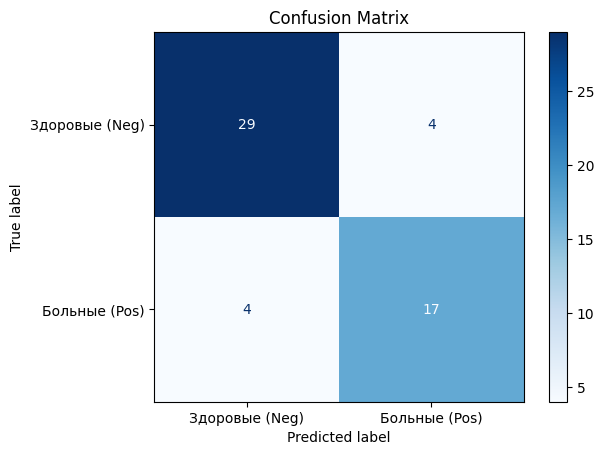

Accuracy: 0.8148148148148148

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86        33
           1       0.92      0.57      0.71        21

    accuracy                           0.81        54
   macro avg       0.85      0.77      0.79        54
weighted avg       0.84      0.81      0.80        54

Confusion matrix:
 [[32  1]
 [ 9 12]]


In [463]:
clf = DecisionTreeClassifier(random_state=42, max_depth=4)
clf.fit(X_train, y_train)

y_pred_test = clf.predict(X_test)
y_prob_test = clf.predict_proba(X_test)[:, 1]

pretty_metrics_with_plot(y_test, y_pred_test, y_prob_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


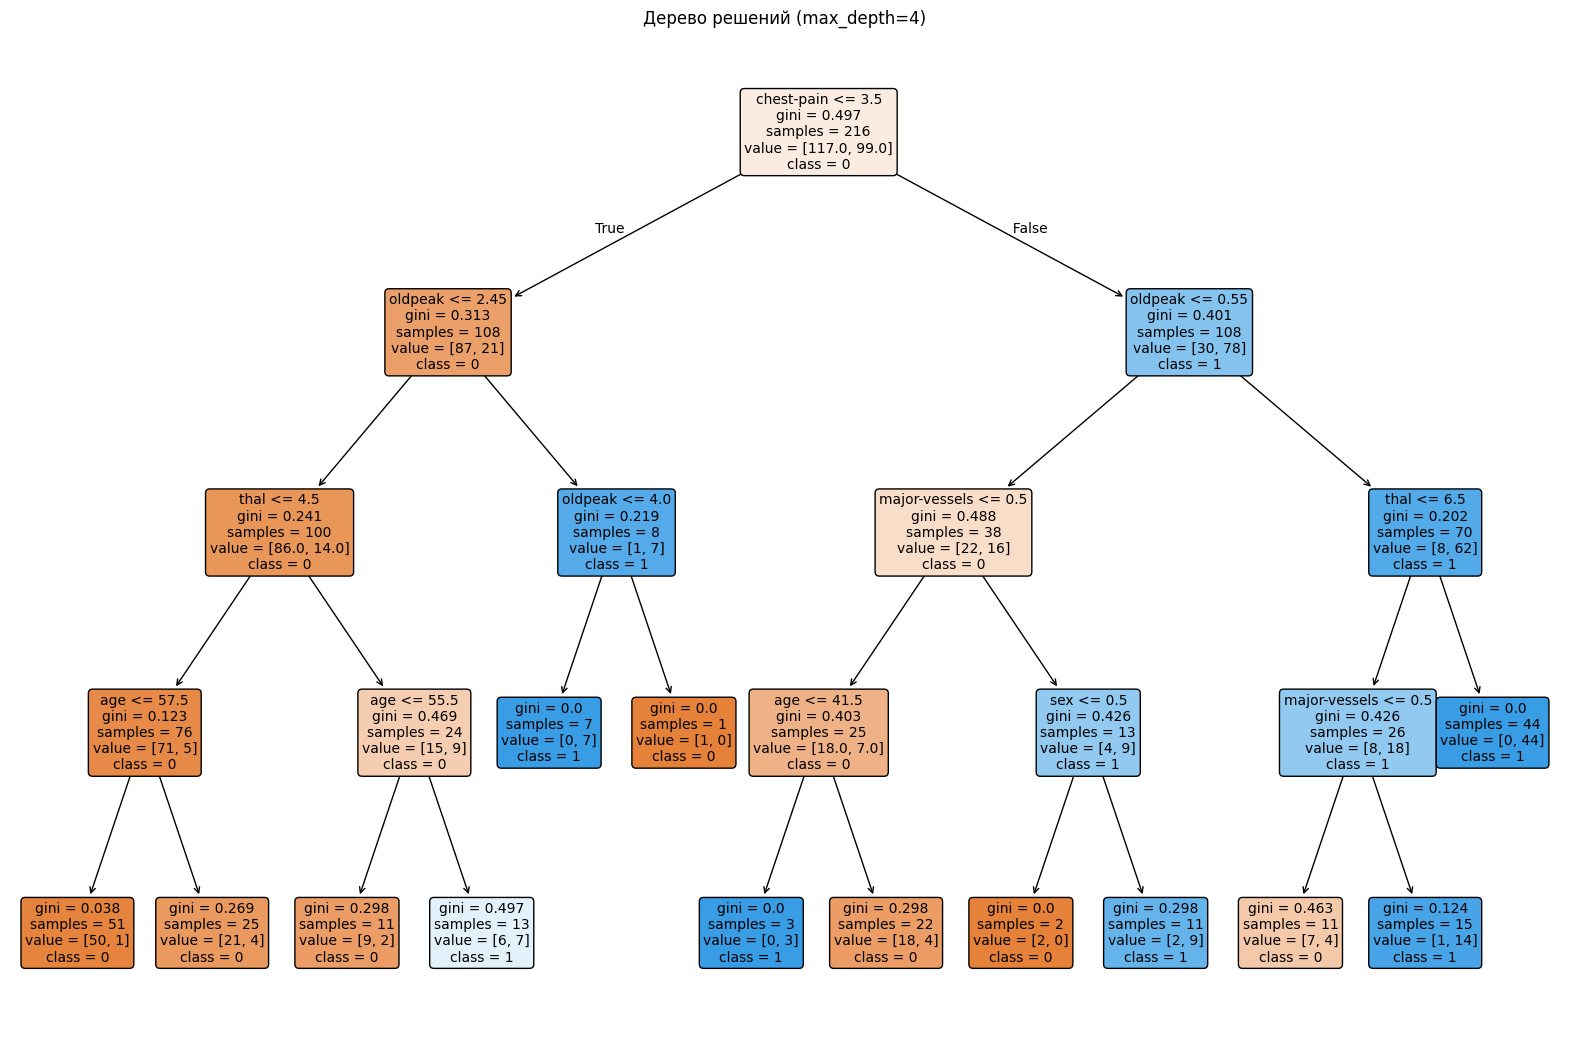

In [464]:
from sklearn.tree import plot_tree

feature_names = [col for col in df.columns if col != 'target']

plt.figure(figsize=(20, 13))
plot_tree(clf, 
          feature_names=feature_names,
          class_names=[str(x) for x in clf.classes_],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений (max_depth=4)")
plt.show()

# Метод ближайших соседей

,Value
Accuracy,0.8148
Precision (binary),0.9231
Recall (binary),0.5714
F1-score (binary),0.7059
Precision (macro),0.8518
Recall (macro),0.7706
F1-score (macro),0.7854
Precision (micro),0.8148
Recall (micro),0.8148
F1-score (micro),0.8148


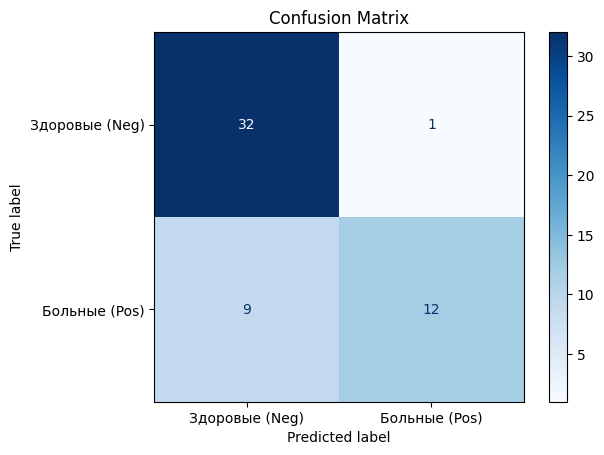

Accuracy: 0.8148148148148148

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.97      0.86        33
           1       0.92      0.57      0.71        21

    accuracy                           0.81        54
   macro avg       0.85      0.77      0.79        54
weighted avg       0.84      0.81      0.80        54

Confusion matrix:
 [[32  1]
 [ 9 12]]


In [465]:
from sklearn.neighbors import KNeighborsClassifier

# Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# k-NN
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train_scaled, y_train)

# Предсказания
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]  # <- Важно! только столбец класса 1

# Вывод метрик
pretty_metrics_with_plot(y_test, y_pred, y_pred_proba)

# Классический отчет
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))